In [52]:
import numpy as np
from typing import Tuple
from matplotlib import pyplot as plt

# State Transition Matrix

In [30]:
"""
Inputs:
1. P: Transition probability matrix of size (n, n) where n is the number of states.
2. s: Current state (integer index).
3. all_s: List of all possible states.
"""
def stateTransition(P: np.ndarray, s: int, all_s: list[int]) -> int:

    # get transition probabilities for this state
    tP = P[s]

    # sample the next state, with tP probabilities
    next_s = np.random.choice(all_s, p=tP)

    return next_s

# Reward Function

Expected value of rewards obtained when state transition happends: s_t --> st_(t+1)
Current state is s_t

In [31]:
"""
Inputs:
1. s: current state (integer index).
2. P: Transition probability matrix of size (n, n) where n is the number of states.
3. R: Reward function, a dictionary mapping state index to reward value.
"""

def rewardFunction(s: int, P: np.ndarray, R: dict)-> float:

    # find all possible next states, and their probabilities
    nextStateProbs = P[s]

    # do a weighted average with all states, and their rewards
    reward = np.average(list(R.values()), weights=nextStateProbs)

    return reward

# MDP
1. States
2. State transition probability matrix
3. Reward function

In [32]:
S = {'Class1': 0, 'Class2': 1, 'Class3': 2, 'Pass': 3, 'Pub': 4, 'Facebook': 5, 'Sleep': 6}
R = {'Class1': -2, 'Class2': -2, 'Class3': -2, 'Pass': 10, 'Pub': 1, 'Facebook': -1, 'Sleep': 0}

Sinv = {v: k for k, v in S.items()}
Rinv = {v: k for k, v in R.items()}

allStates = list(S.values())
P = np.array([[0.0, 0.5, 0.0, 0.0, 0.0, 0.5, 0.0],
              [0.0, 0.0, 0.8, 0.0, 0.0, 0.0, 0.2],
              [0.0, 0.0, 0.0, 0.6, 0.4, 0.0, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],
              [0.2, 0.4, 0.4, 0.0, 0.0, 0.0, 0.0],
              [0.1, 0.0, 0.0, 0.0, 0.0, 0.9, 0.0],
              [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0],]) 

# Run a Markov Chain

In [ ]:
gamma = 0.8
timeSteps = 100

"""
Inputs:
1. P: Transition probability matrix of size (n, n) where n is the number of states.
2. R: Reward function, a dictionary mapping state index to reward value.
3. Sinv: Inverse mapping of state index to state name
4. timeSteps: Number of time steps to simulate, an integer.
5. S0: Initial state (integer index). [Optional]
"""

def simulateMDP(P: np.ndarray, 
                R: dict, 
                Sinv: dict,
                timeSteps: int, 
                S0: int = 0) -> Tuple[list[int], list[float]]:

    # create array to store consecutive states, and rewards and returns
    states = np.zeros(timeSteps, dtype=int)
    rewards = np.zeros(timeSteps-1, dtype=float) # rewards are for transitions, so one less than states

    states[0] = S0

    # loop for the number of time steps
    for t in range(1, timeSteps):

        # get current state
        s = states[t-1]

        # get next state
        states[t] = stateTransition(P, s, allStates)

        # get reward for this transition
        rewards[t-1] = R[Sinv[states[t]]]
    
    return states, rewards

In [70]:
# run a chain of states and rewards
states, rewards = simulateMDP(P, R, Sinv, timeSteps)

# After the loop, compute discounted returns backwards
returns = np.zeros_like(rewards)
returns[-1] = rewards[-1]
for t in range(timeSteps - 3, -1, -1):
    returns[t] = rewards[t] + gamma * returns[t+1]

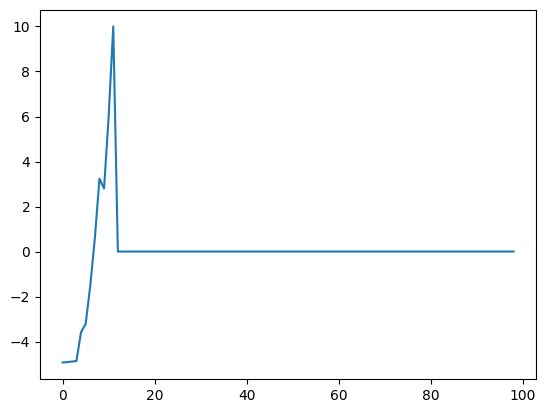

In [71]:
plt.plot(returns)